In [1]:
import pandas as pd

df = pd.read_excel("data/Online Retail.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Rows and Columns: (541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


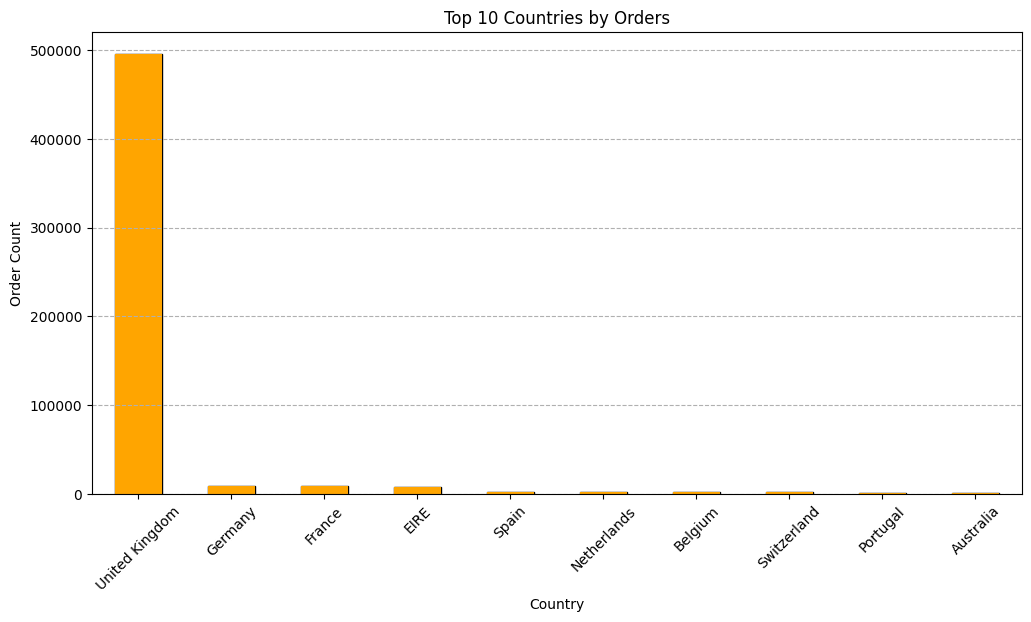

In [16]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_countries.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Orders")
top_countries.plot(kind="bar", color="orange")
plt.xlabel("Country")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

plt.show()

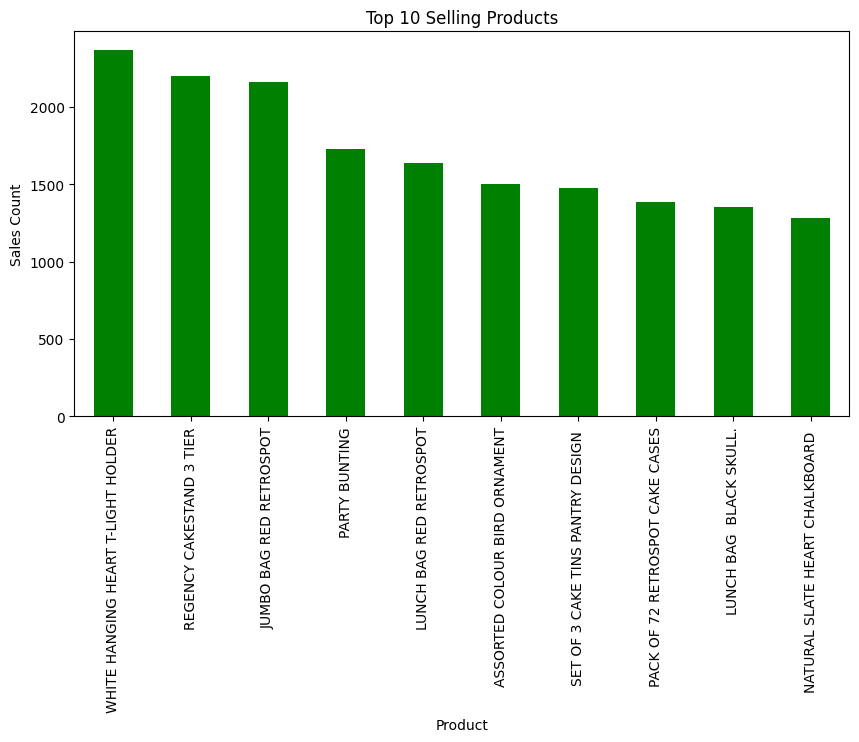

In [11]:
top_products = df["Description"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar", color="Green")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales Count")
plt.xticks(rotation=90)
plt.show()

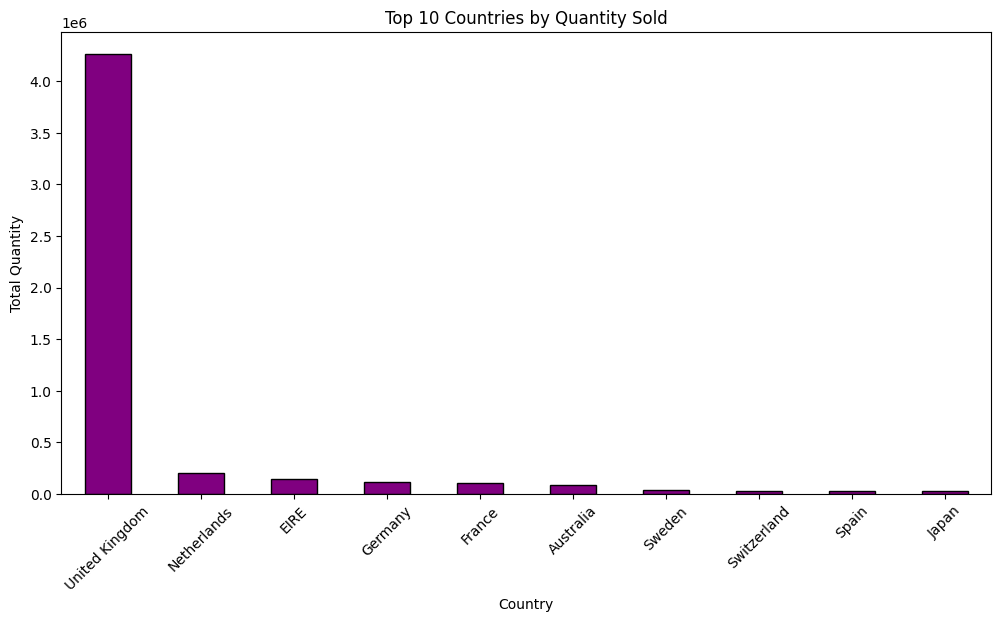

In [13]:
sales_by_country = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sales_by_country.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Top 10 Countries by Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.show()

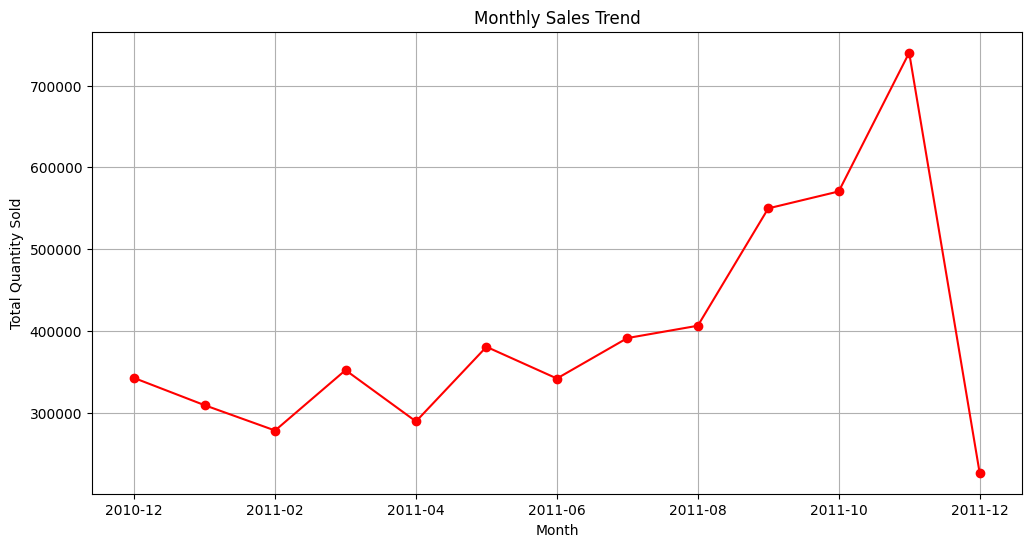

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_sales = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["Quantity"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind="line",
    color="red",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.grid(True)

plt.show()

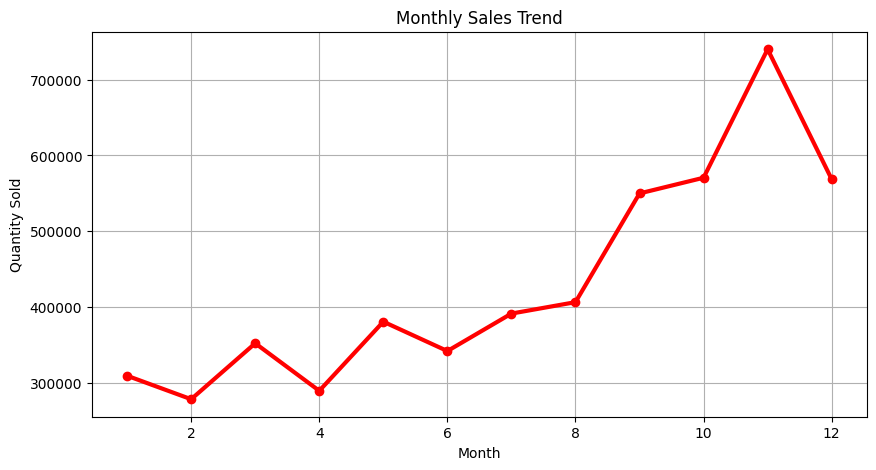

In [17]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.month)["Quantity"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(
    kind="line",
    color="red",
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.grid(True)
plt.show()